# Read Database

In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('bmarket.db')

sql_query = "SELECT * FROM bank_marketing"

df = pd.read_sql(sql_query, conn)

conn.close()

df.head()

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57 years,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,Cell,2,999,no


# Initial Data Understanding and Insights

In [3]:
#
# *** Insights from running .info() ****
#
# Housing Loan and Personal Loan Columns have a lot of missing data
# Age column is of type 'object', should be changed to 'int'
#

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client ID              41188 non-null  int64 
 1   Age                    41188 non-null  object
 2   Occupation             41188 non-null  object
 3   Marital Status         41188 non-null  object
 4   Education Level        41188 non-null  object
 5   Credit Default         41188 non-null  object
 6   Housing Loan           16399 non-null  object
 7   Personal Loan          37042 non-null  object
 8   Contact Method         41188 non-null  object
 9   Campaign Calls         41188 non-null  int64 
 10  Previous Contact Days  41188 non-null  int64 
 11  Subscription Status    41188 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


In [4]:
#
# Check dataset for duplicates
# *** Insights ****
#
# No duplicates in data
#

print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


# For Campaign Call Correlation, remove later

In [5]:
print(list(df.columns))

for tag in list(df.columns):
    print(f"\n {tag}: {df[tag].unique()}")

['Client ID', 'Age', 'Occupation', 'Marital Status', 'Education Level', 'Credit Default', 'Housing Loan', 'Personal Loan', 'Contact Method', 'Campaign Calls', 'Previous Contact Days', 'Subscription Status']

 Client ID: [32885  3170 32207 ... 38159   861 15796]

 Age: ['57 years' '55 years' '33 years' '36 years' '27 years' '58 years'
 '48 years' '150 years' '24 years' '34 years' '42 years' '43 years'
 '26 years' '37 years' '46 years' '59 years' '49 years' '30 years'
 '51 years' '45 years' '31 years' '41 years' '38 years' '47 years'
 '69 years' '50 years' '25 years' '39 years' '44 years' '52 years'
 '35 years' '77 years' '40 years' '56 years' '53 years' '60 years'
 '29 years' '28 years' '54 years' '32 years' '81 years' '63 years'
 '21 years' '22 years' '74 years' '80 years' '62 years' '68 years'
 '86 years' '23 years' '71 years' '67 years' '65 years' '20 years'
 '19 years' '66 years' '75 years' '18 years' '72 years' '70 years'
 '82 years' '85 years' '61 years' '88 years' '83 years' '78 

This is to check the type of tags within the information

In [6]:
df_copy = df.copy()
df_copy["Age"] = df_copy["Age"].apply(lambda x: int(x.split()[0]))
df_copy

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27,housemaid,married,high.school,no,None,no,Cell,2,999,no
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58,retired,married,professional.course,unknown,no,no,Telephone,2,999,no
41184,11285,37,management,married,university.degree,no,no,no,telephone,1,999,no
41185,38159,35,admin.,married,high.school,no,None,no,cellular,1,4,yes
41186,861,40,management,married,university.degree,no,None,no,telephone,2,999,no


In [7]:
df_copy['Contact Method'] = df_copy['Contact Method'].str.lower().str.strip()

df_copy['Contact Method'] = df_copy['Contact Method'].replace({
    'cell': 'cellular', 'Telephone': 'telephone'})

df_copy['Housing Loan'] = df_copy['Housing Loan'].replace({ None: "unknown" })

df_copy['Personal Loan'] = df_copy['Personal Loan'].replace({ None: "unknown" })

In [8]:
df_copy['Contact Method'].value_counts()

Contact Method
cellular     26144
telephone    15044
Name: count, dtype: int64

In [9]:
df_copy['Personal Loan'].value_counts()

Personal Loan
no         30532
yes         5633
unknown     5023
Name: count, dtype: int64

In [10]:
df_copy["Housing Loan"].value_counts()

Housing Loan
unknown    25182
yes         8595
no          7411
Name: count, dtype: int64

In [11]:
df_copy["Marital Status"].value_counts()

Marital Status
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [59]:
df_copy["Credit Default"].value_counts()

Credit Default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [12]:
df_copy['Subscription Status'] = df_copy['Subscription Status'].replace({ "no" : 0, "yes": 1 })

df_negative_calls = df_copy[df_copy["Campaign Calls"] < 0]
df_positive_calls = df_copy[df_copy["Campaign Calls"] >= 0]

C:\Users\Yik Heng\AppData\Local\Temp\ipykernel_26180\1158454524.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['Subscription Status'] = df_copy['Subscription Status'].replace({ "no" : 0, "yes": 1 })


In [13]:
df_negative_calls.drop(columns=["Client ID", "Age"], inplace=True)
df_positive_calls.drop(columns=["Client ID", "Age"], inplace=True)

C:\Users\Yik Heng\AppData\Local\Temp\ipykernel_26180\1864044228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_negative_calls.drop(columns=["Client ID", "Age"], inplace=True)
C:\Users\Yik Heng\AppData\Local\Temp\ipykernel_26180\1864044228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_positive_calls.drop(columns=["Client ID", "Age"], inplace=True)


C:\Users\Yik Heng\AppData\Local\Temp\ipykernel_26180\3325005599.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


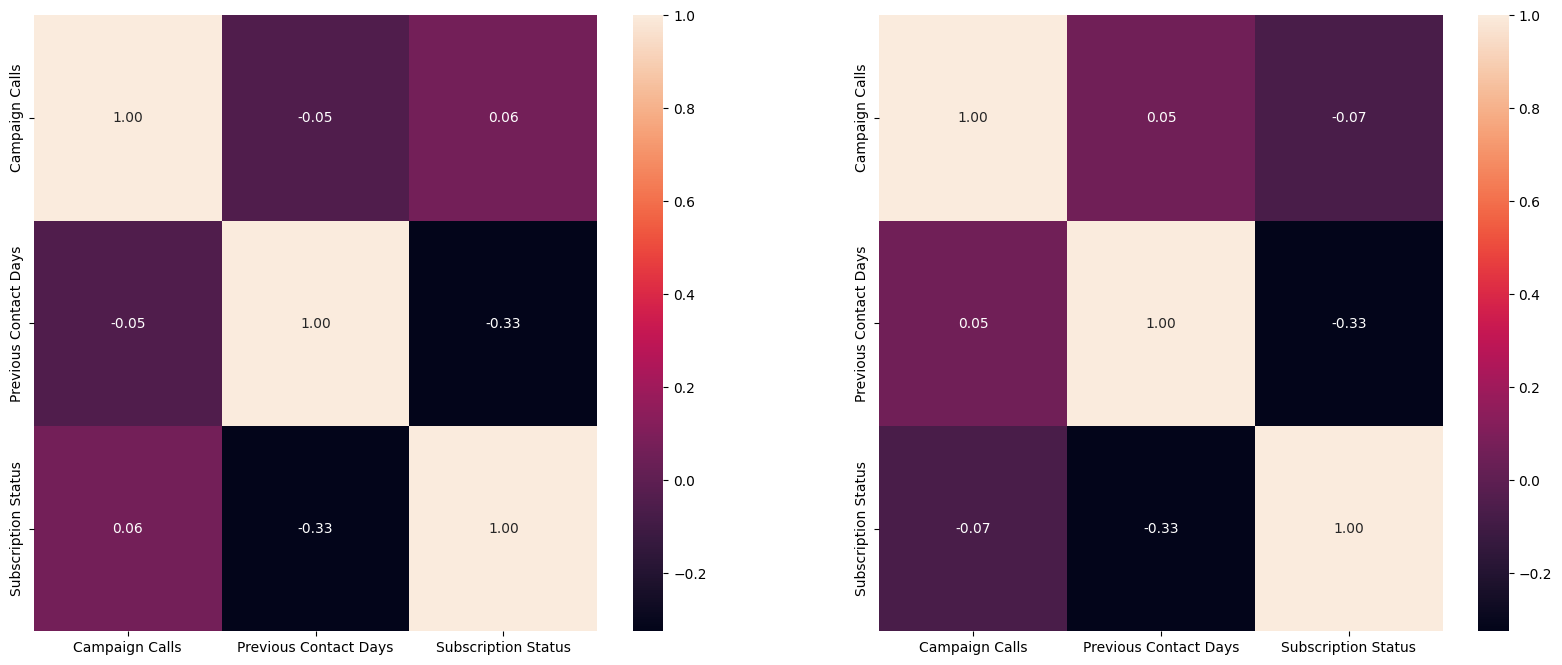

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2 , figsize=(20, 8))
sns.heatmap(df_negative_calls.corr(numeric_only=True), annot=True, fmt=".2f", ax=ax[0])
sns.heatmap(df_positive_calls.corr(numeric_only=True), annot=True, fmt=".2f", ax=ax[1])
fig.show()

In [15]:
df_copy["Campaign Calls"] = df_copy["Campaign Calls"].abs()
df_copy

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57,technician,married,high.school,no,no,yes,cellular,1,999,0
1,3170,55,unknown,married,unknown,unknown,yes,no,telephone,2,999,0
2,32207,33,blue-collar,married,basic.9y,no,no,no,cellular,1,999,0
3,9404,36,admin.,married,high.school,no,no,no,telephone,4,999,0
4,14021,27,housemaid,married,high.school,no,unknown,no,cellular,2,999,0
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58,retired,married,professional.course,unknown,no,no,telephone,2,999,0
41184,11285,37,management,married,university.degree,no,no,no,telephone,1,999,0
41185,38159,35,admin.,married,high.school,no,unknown,no,cellular,1,4,1
41186,861,40,management,married,university.degree,no,unknown,no,telephone,2,999,0


## Correlation Coefficient

In [16]:
str_columns = df_copy.select_dtypes(include=['object']).columns.tolist()
str_columns

['Occupation',
 'Marital Status',
 'Education Level',
 'Credit Default',
 'Housing Loan',
 'Personal Loan',
 'Contact Method']

Label encoding below

In [17]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

df_label_encoded = df.copy()
df_label_encoded.drop(columns=["Client ID"], inplace=True)
str_columns = df_copy.select_dtypes(include=['object']).columns.tolist()

for col in str_columns:
    df_label_encoded[col] = labelencoder.fit_transform(df_label_encoded[col])

df_label_encoded

,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,57 years,9,1,3,0,0,2,0,1,999,no
1,55 years,11,1,7,1,2,0,3,2,999,no
2,33 years,1,1,2,0,0,0,2,1,999,no
3,36 years,0,1,3,0,0,0,1,4,999,no
4,27 years,3,1,3,0,3,0,0,2,999,no
...,...,...,...,...,...,...,...,...,...,...,...
41183,58 years,5,1,5,1,0,0,1,2,999,no
41184,37 years,4,1,6,0,0,0,3,1,999,no
41185,35 years,0,1,3,0,3,0,2,1,4,yes
41186,40 years,4,1,6,0,3,0,3,2,999,no


<Axes: >

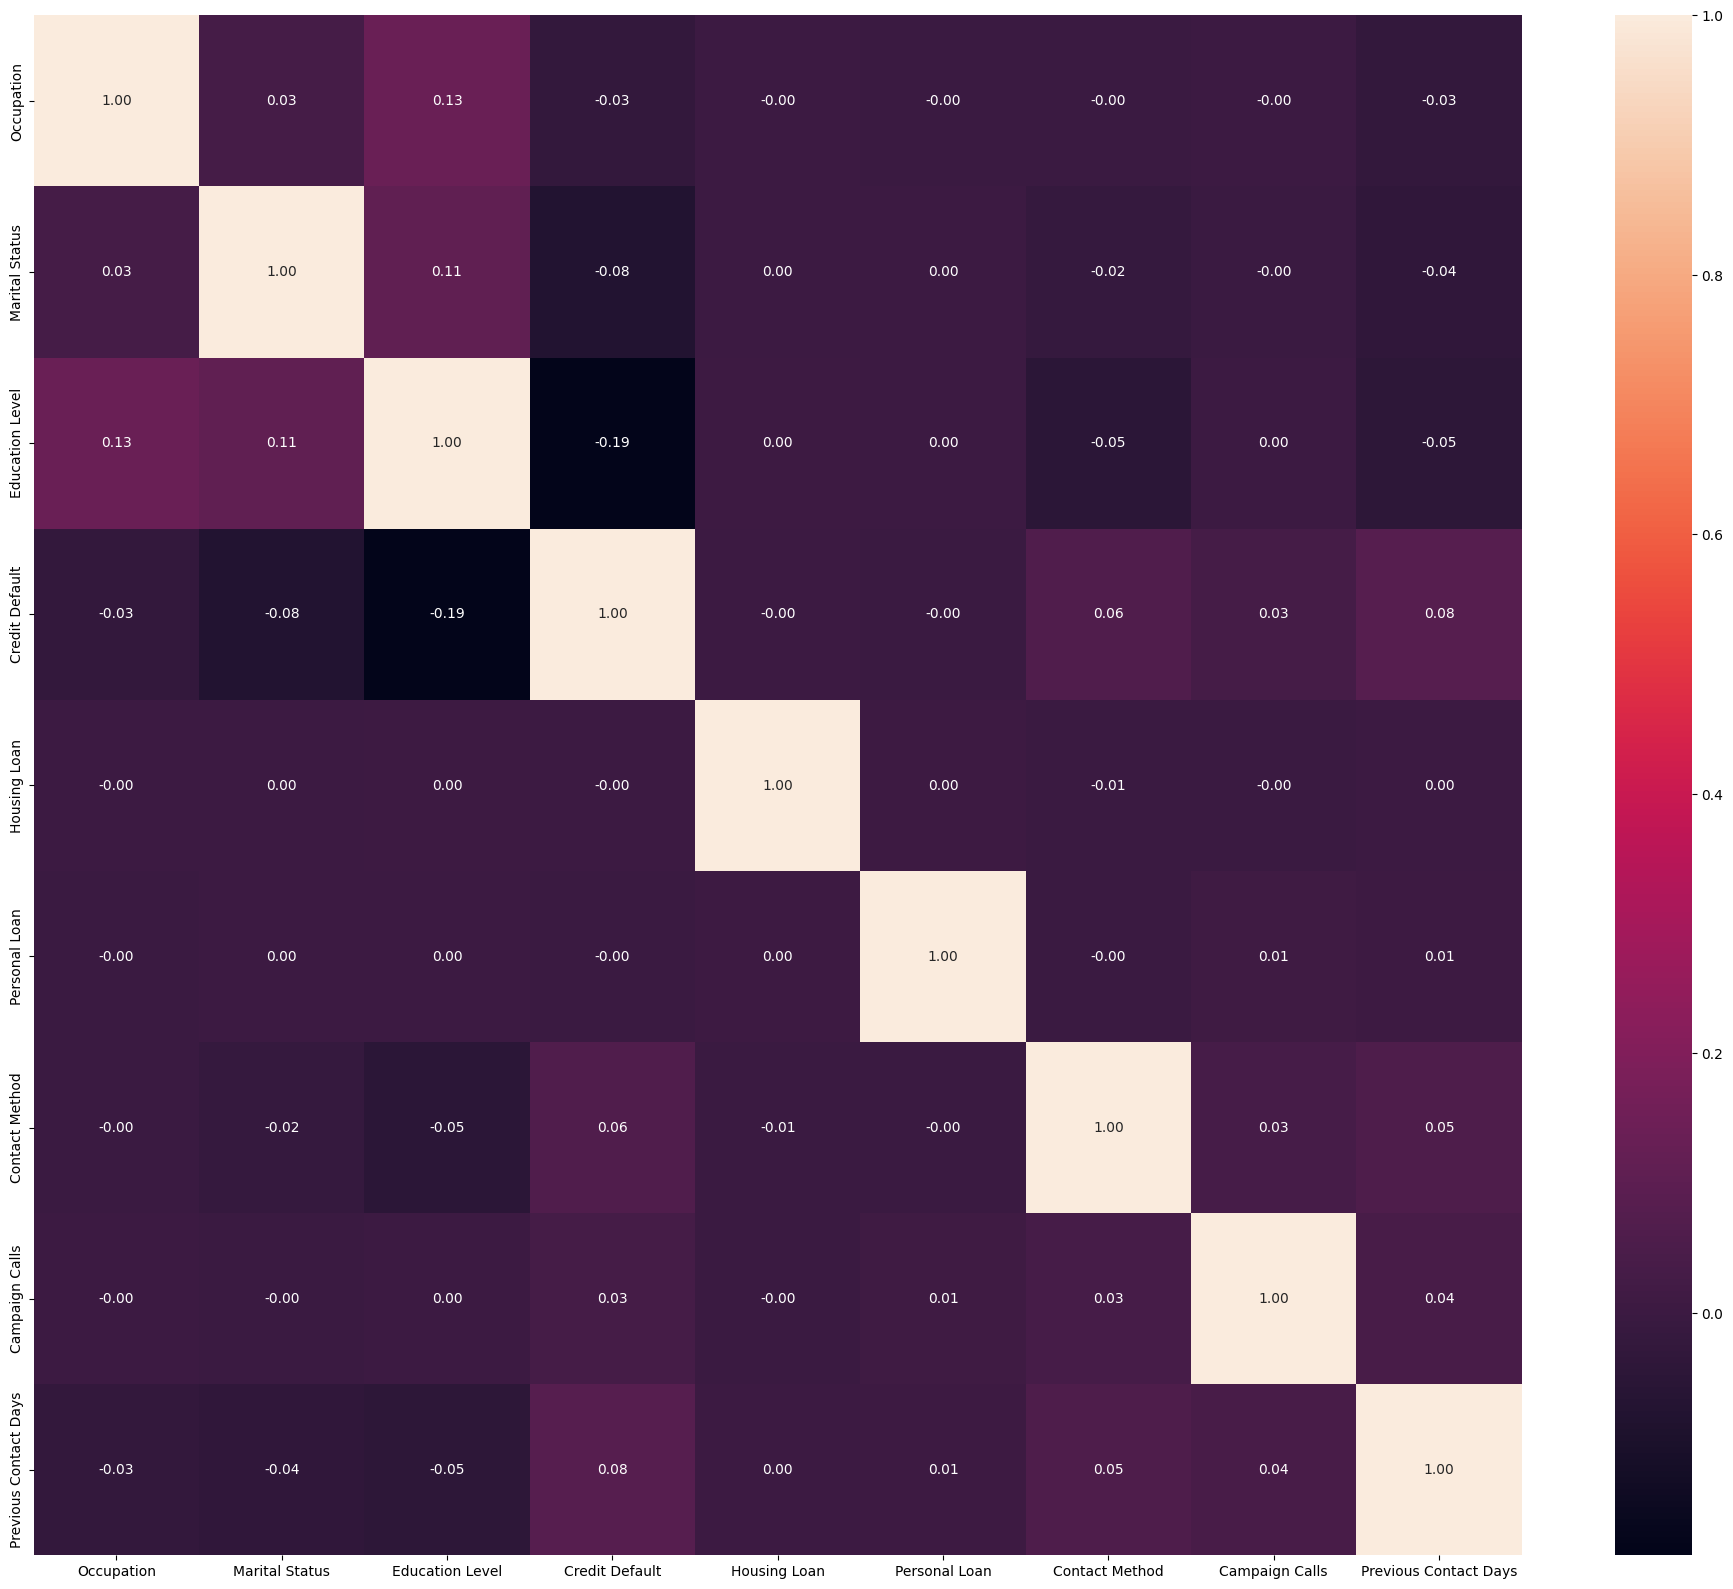

In [18]:
fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(df_label_encoded.corr(numeric_only=True), annot=True, fmt=".2f")

One hot encoder below

In [19]:
df_copy_noID = df.copy()
df_copy_noID.drop(columns=["Client ID"], inplace=True)
str_columns = df_copy.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_copy_noID, columns=str_columns, drop_first=True)
df_encoded['Subscription Status'] = df_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 }).infer_objects(copy=False)
df_encoded

C:\Users\Yik Heng\AppData\Local\Temp\ipykernel_26180\3504736592.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded['Subscription Status'] = df_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 }).infer_objects(copy=False)


,Age,Campaign Calls,Previous Contact Days,Subscription Status,Occupation_blue-collar,Occupation_entrepreneur,Occupation_housemaid,Occupation_management,Occupation_retired,Occupation_self-employed,...,Education Level_unknown,Credit Default_unknown,Credit Default_yes,Housing Loan_unknown,Housing Loan_yes,Personal Loan_unknown,Personal Loan_yes,Contact Method_Telephone,Contact Method_cellular,Contact Method_telephone
0,57 years,1,999,0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,55 years,2,999,0,False,False,False,False,False,False,...,True,True,False,False,True,False,False,False,False,True
2,33 years,1,999,0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,36 years,4,999,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,27 years,2,999,0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,58 years,2,999,0,False,False,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False
41184,37 years,1,999,0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
41185,35 years,1,4,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
41186,40 years,2,999,0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


### One Hot Encoding for Occupation

In [20]:
df_encoded_occupation = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Occupation_' not in col])
df_encoded_occupation = pd.concat([df_encoded_occupation, df_encoded['Subscription Status']], axis=1)
df_encoded_occupation

,Occupation_blue-collar,Occupation_entrepreneur,Occupation_housemaid,Occupation_management,Occupation_retired,Occupation_self-employed,Occupation_services,Occupation_student,Occupation_technician,Occupation_unemployed,Occupation_unknown,Subscription Status
0,False,False,False,False,False,False,False,False,True,False,False,0
1,False,False,False,False,False,False,False,False,False,False,True,0
2,True,False,False,False,False,False,False,False,False,False,False,0
3,False,False,False,False,False,False,False,False,False,False,False,0
4,False,False,True,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,False,False,False,False,True,False,False,False,False,False,False,0
41184,False,False,False,True,False,False,False,False,False,False,False,0
41185,False,False,False,False,False,False,False,False,False,False,False,1
41186,False,False,False,True,False,False,False,False,False,False,False,0


<Axes: >

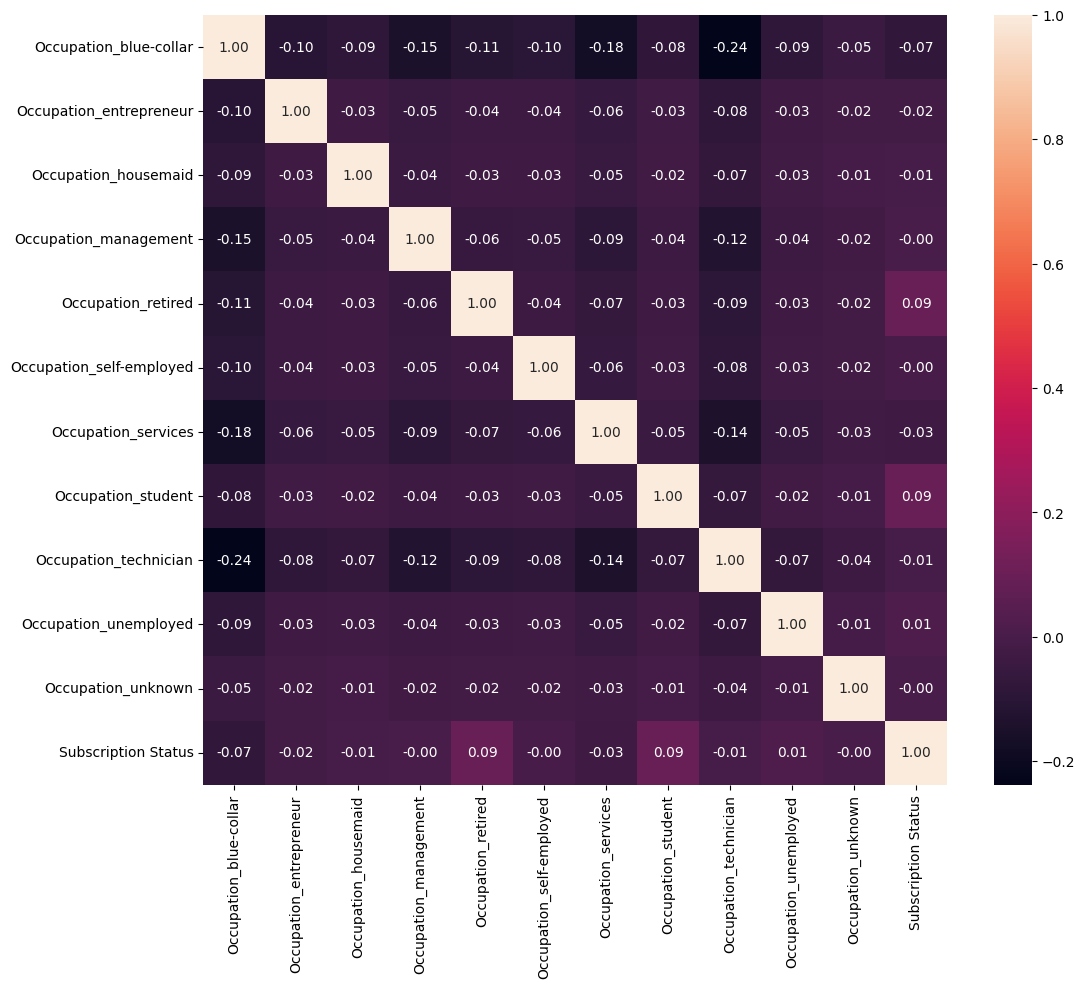

In [21]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_occupation.corr(numeric_only=True), annot=True, fmt=".2f")

### One Hot Encoding for Marital Status

In [22]:
df_encoded_marital_status = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Marital Status_' not in col])
df_encoded_marital_status = pd.concat([df_encoded_marital_status, df_encoded['Subscription Status']], axis=1)
df_encoded_marital_status

,Marital Status_married,Marital Status_single,Marital Status_unknown,Subscription Status
0,True,False,False,0
1,True,False,False,0
2,True,False,False,0
3,True,False,False,0
4,True,False,False,0
...,...,...,...,...
41183,True,False,False,0
41184,True,False,False,0
41185,True,False,False,1
41186,True,False,False,0


<Axes: >

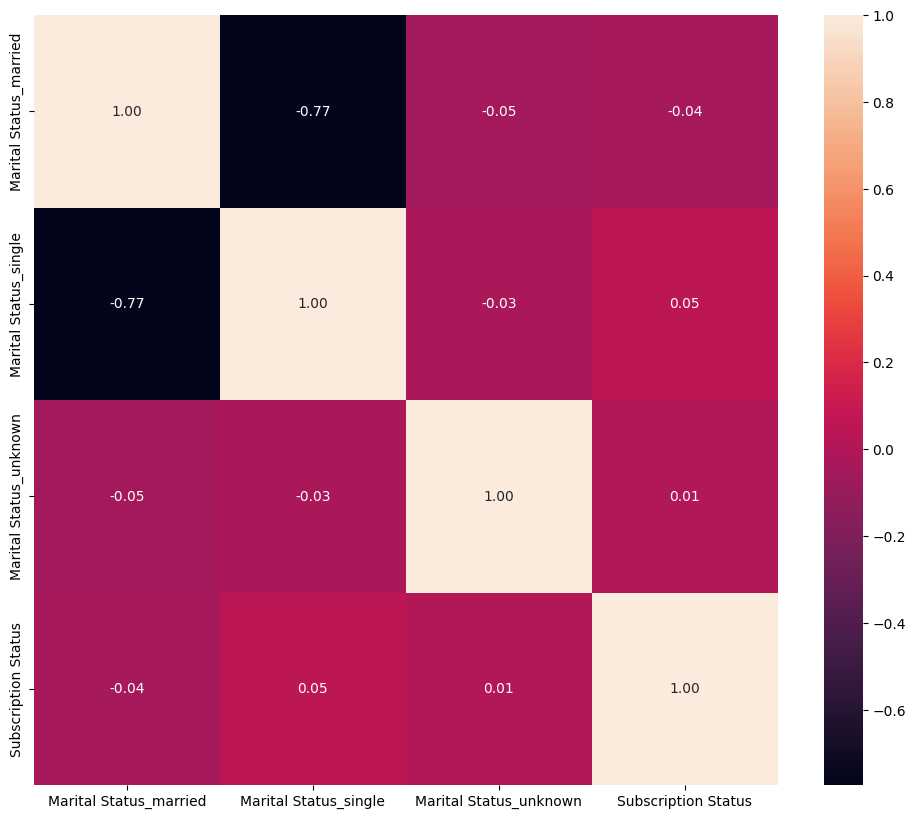

In [23]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_marital_status.corr(numeric_only=True), annot=True, fmt=".2f")

### One Hot Encoding for Education Level

In [24]:
df_encoded_education = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Education Level_' not in col])
df_encoded_education = pd.concat([df_encoded_education, df_encoded['Subscription Status']], axis=1)
df_encoded_education

,Education Level_basic.6y,Education Level_basic.9y,Education Level_high.school,Education Level_illiterate,Education Level_professional.course,Education Level_university.degree,Education Level_unknown,Subscription Status
0,False,False,True,False,False,False,False,0
1,False,False,False,False,False,False,True,0
2,False,True,False,False,False,False,False,0
3,False,False,True,False,False,False,False,0
4,False,False,True,False,False,False,False,0
...,...,...,...,...,...,...,...,...
41183,False,False,False,False,True,False,False,0
41184,False,False,False,False,False,True,False,0
41185,False,False,True,False,False,False,False,1
41186,False,False,False,False,False,True,False,0


<Axes: >

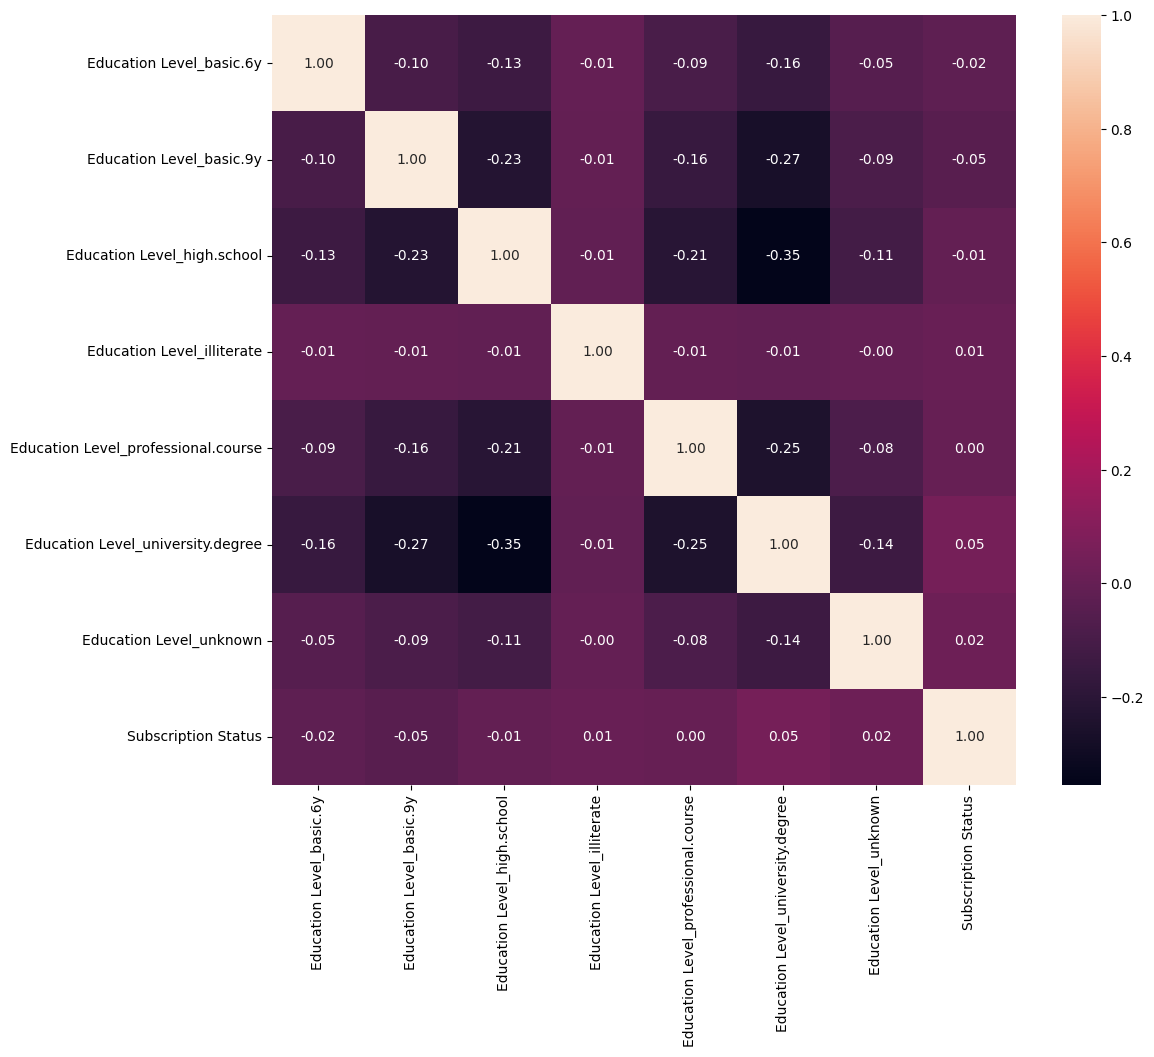

In [25]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_education.corr(numeric_only=True), annot=True, fmt=".2f")

### One Hot Encode for Personal Loan

In [26]:
df_encoded_personal_loan = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Personal Loan_' not in col])
df_encoded_personal_loan = pd.concat([df_encoded_personal_loan, df_encoded['Subscription Status']], axis=1)
df_encoded_personal_loan

,Personal Loan_unknown,Personal Loan_yes,Subscription Status
0,False,True,0
1,False,False,0
2,False,False,0
3,False,False,0
4,False,False,0
...,...,...,...
41183,False,False,0
41184,False,False,0
41185,False,False,1
41186,False,False,0


<Axes: >

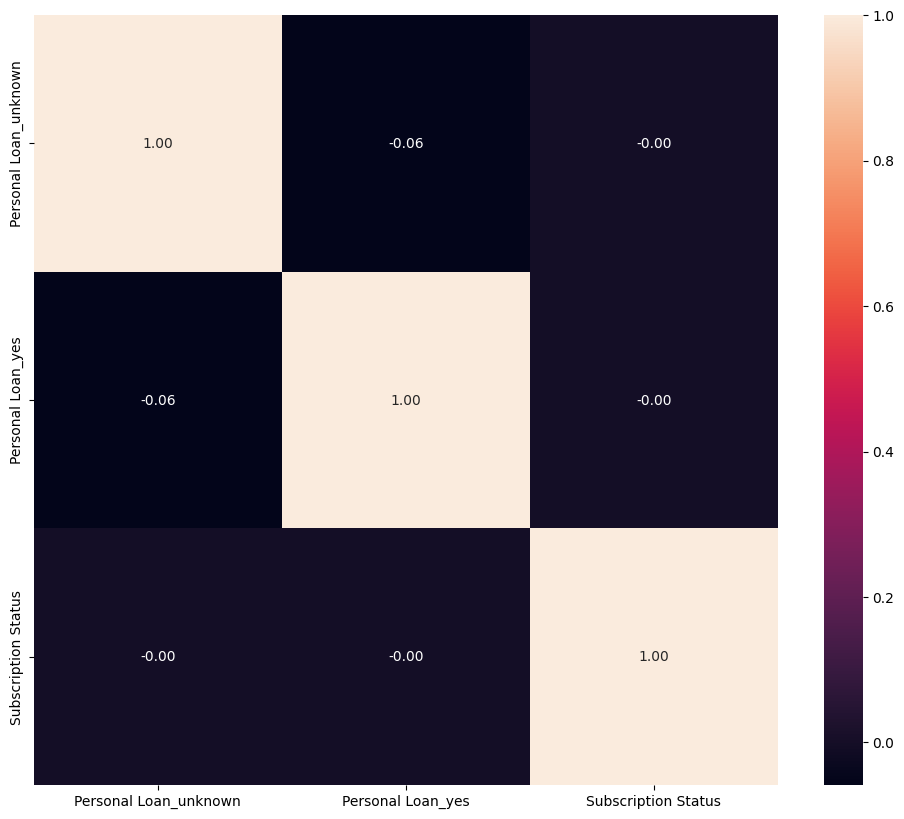

In [27]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_personal_loan.corr(numeric_only=True), annot=True, fmt=".2f")

### One Hot Encode Credi Default

In [28]:
df_encoded_credit = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Credit Default_' not in col])
df_encoded_credit = pd.concat([df_encoded_credit, df_encoded['Subscription Status']], axis=1)
df_encoded_credit

,Credit Default_unknown,Credit Default_yes,Subscription Status
0,False,False,0
1,True,False,0
2,False,False,0
3,False,False,0
4,False,False,0
...,...,...,...
41183,True,False,0
41184,False,False,0
41185,False,False,1
41186,False,False,0


<Axes: >

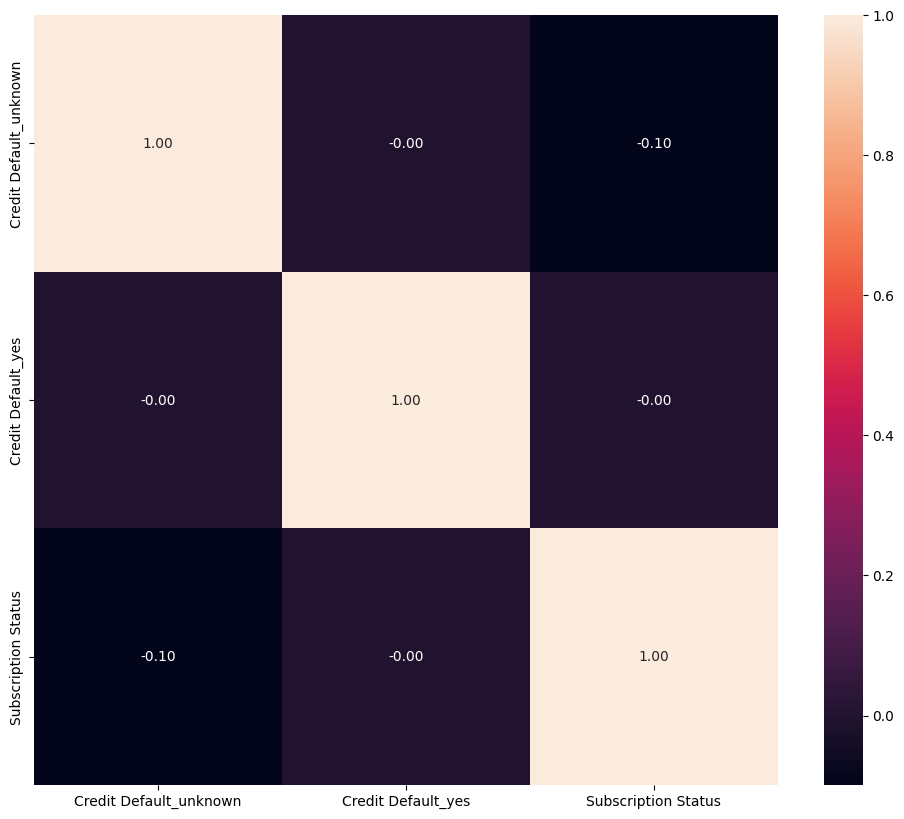

In [29]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_credit.corr(numeric_only=True), annot=True, fmt=".2f")

### Others

In [30]:
df_encoded_rest = df_encoded.drop(columns=[col for col in df_encoded.columns if ('Occupation_' in col) or ('Marital Status_' in col) or ('Education Level_' in col) or ('Personal Loan_' in col) or ('Credit Default_' in col)])
df_encoded_rest

,Age,Campaign Calls,Previous Contact Days,Subscription Status,Housing Loan_unknown,Housing Loan_yes,Contact Method_Telephone,Contact Method_cellular,Contact Method_telephone
0,57 years,1,999,0,False,False,False,False,False
1,55 years,2,999,0,False,True,False,False,True
2,33 years,1,999,0,False,False,False,True,False
3,36 years,4,999,0,False,False,True,False,False
4,27 years,2,999,0,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
41183,58 years,2,999,0,False,False,True,False,False
41184,37 years,1,999,0,False,False,False,False,True
41185,35 years,1,4,1,False,False,False,True,False
41186,40 years,2,999,0,False,False,False,False,True


<Axes: >

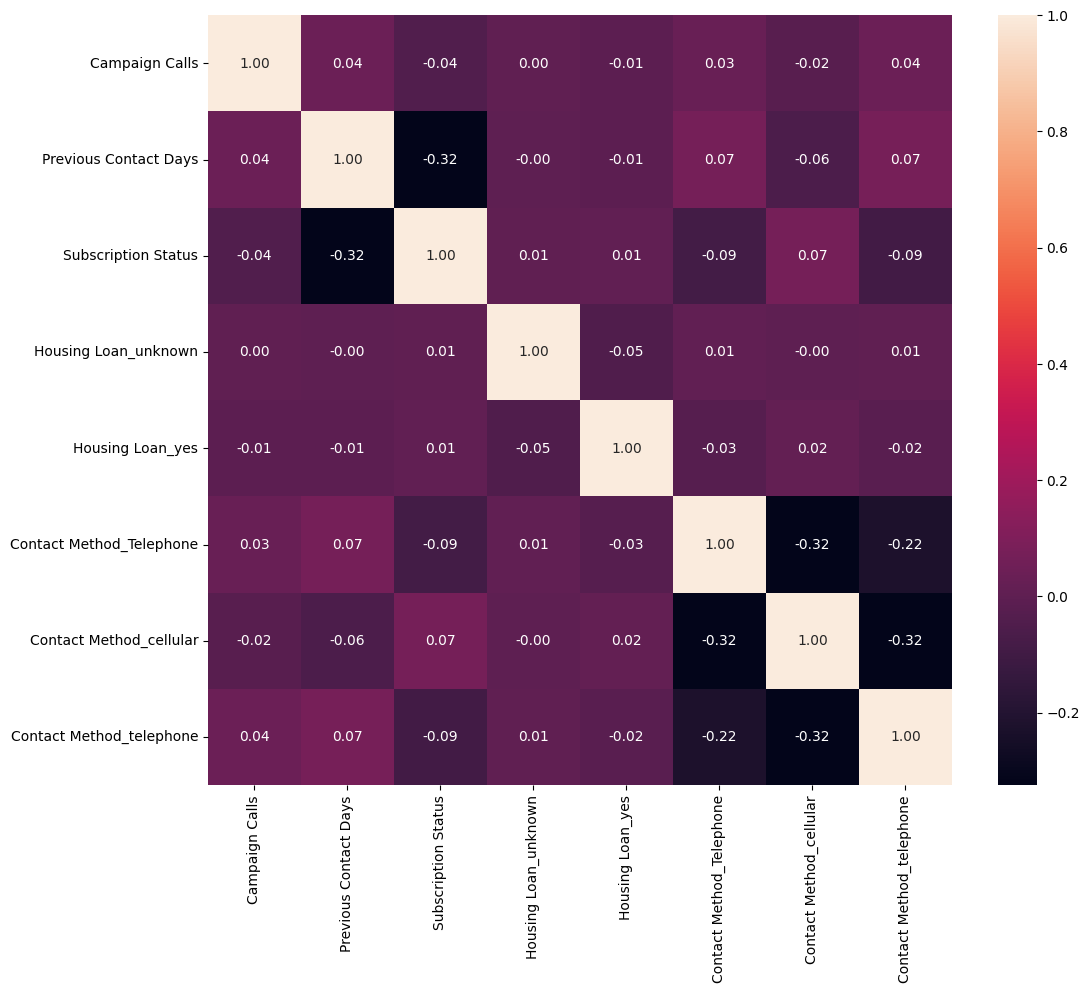

In [31]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_rest.corr(numeric_only=True), annot=True, fmt=".2f")

# Jade eda

In this project, I focus on four key attributes:
-Age (Numerical and optionally grouped)  -Credit Default (Categorial: yes/no/unknown) -Contact Method (Categorical: cellular/telephone) -Subscription Status (Target: yes/no)

In [32]:
df_eda = df.copy()

# df_eda["Subscription Status"] = df_eda["Subscription Status"].replace({"yes": 1, "no": 0}).astype(int)

# df_eda["Subscription Status"].value_counts(dropna=False)
# df_eda["Subscription Status"].dtype


In [33]:
df_eda["Age"] = df_eda["Age"].apply(lambda x: int(x.split()[0]))

In [34]:
print("Min age:", df_eda["Age"].min())
print("Max age:", df_eda["Age"].max())

Min age: 17
Max age: 150


In [35]:
df_eda["Age"].describe()

count    41188.000000
mean        51.231572
std         34.708486
min         17.000000
25%         33.000000
50%         40.000000
75%         51.000000
max        150.000000
Name: Age, dtype: float64

In [36]:
df_eda2 = df_eda.copy()

In [37]:
print("Min age:", df_eda2["Age"].min())
print("Max age:", df_eda2["Age"].max())

Min age: 17
Max age: 150


In [38]:
median_age = df_eda2.loc[df_eda2["Age"] < 100, 'Age'].median()
df_eda2.loc[df_eda2["Age"] > 100, "Age"] = median_age

In [39]:
median_age


np.float64(38.0)

In [40]:
bins = [0, 29, 49, 59, 100]
labels = ['Youth', 'Adult','Middle-Aged Adults','Elderly']

df_eda2['Age_group'] = pd.cut(df_eda2['Age'], bins = bins, labels = labels)
df_eda2[['Age','Age_group']]


,Age,Age_group
0,57,Middle-Aged Adults
1,55,Middle-Aged Adults
2,33,Adult
3,36,Adult
4,27,Youth
...,...,...
41183,58,Middle-Aged Adults
41184,37,Adult
41185,35,Adult
41186,40,Adult


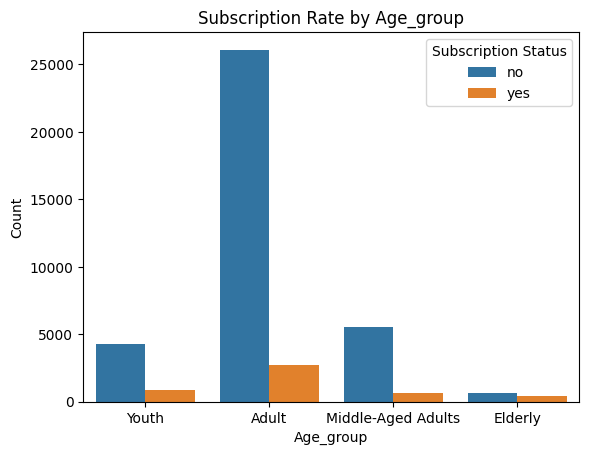

In [41]:
sns.countplot(
    data=df_eda2,
    x="Age_group",
    hue="Subscription Status"
)
plt.ylabel("Count")
plt.title("Subscription Rate by Age_group")
plt.show()

I compute subscription rate (in %) for each category in a column. Subscription Status is assumed to be 0 (no) / 1 (yes)

In [42]:
def sub_rate(df, col):
    return (
        df.groupby(col)["Subscription Status"]
          .mean()
          .mul(100)  
          .reset_index(name="subscription_rate")
          .sort_values("subscription_rate", ascending=False)
    )

- Credit Default Status

Clients with no credit default have the highest subscription rate (~12.9%).
This indicates that financially reliable customers are more responsive to term-deposit promotions.
Customers with unknown credit status show a significantly lower rate (~5.1%), suggesting uncertainty or lack of trust.
Clients who have defaulted previously (yes) do not subscribe at all (0%).

This behaviour aligns with financial principles: customers with credit risk tend to avoid or be excluded from long-term investment products.
It also creates a sparse class problem, where the "yes" group has very few samples.
This may cause instability during model training and should be handled during predictive modelling
(e.g. class weights, grouping yes with unknown, or removing it).

- Contact Method

The Contact Method attribute shows a very strong impact.

Clients contacted via cellular (mobile phone) subscribe at ~14.7%,
more than double the conversion rate of telephone (landline) at ~5.2%.

This suggests that personal phone calls are much more persuasive and effective than traditional landline contact.
The bank should prioritize mobile contact in future campaigns, as it results in higher customer engagement and conversion.

Contact Method vs Subscription

In [43]:
contact_rate = sub_rate(df_copy, "Contact Method")
contact_rate

,Contact Method,subscription_rate
0,cellular,14.737607
1,telephone,5.231321


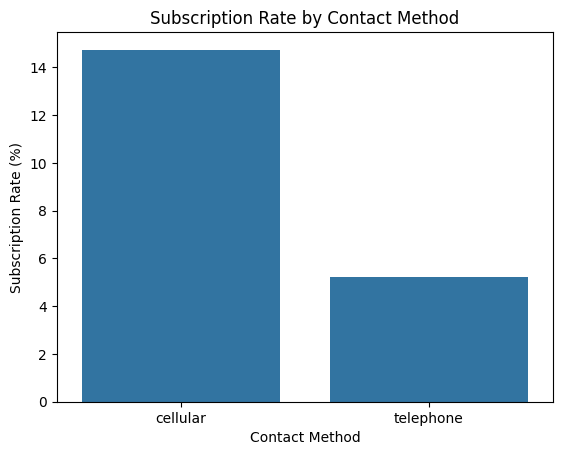

In [44]:
sns.barplot(
    data=contact_rate,
    x="Contact Method",
    y="subscription_rate"
)
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Contact Method")
plt.show()

### Subscription Rate by Contact Method

The bar chart shows that clients contacted via **cellular** have a higher
subscription rate than those contacted via **telephone**.

This suggests that personal mobile contact is a more effective channel
for promoting term deposits compared to traditional landline calls.  
From a marketing perspective, AI-Vive-Banking should prioritise cellular
numbers when planning future campaigns.

Credit Default vs Subscription

In [45]:
credit_rate = sub_rate(df_copy, "Credit Default")
credit_rate

,Credit Default,subscription_rate
0,no,12.878974
1,unknown,5.152960
2,yes,0.000000


In [46]:
df_copy["Credit Default"].value_counts()

Credit Default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

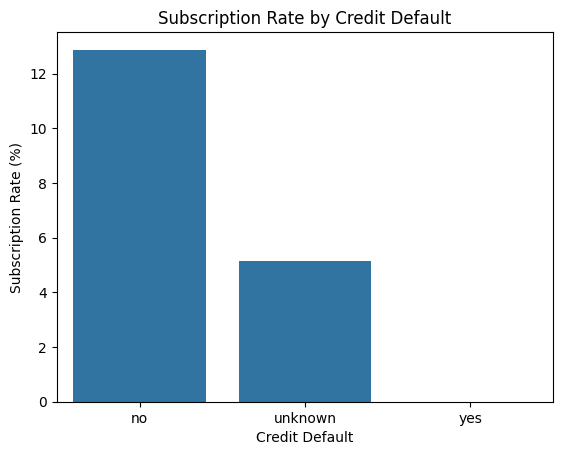

In [47]:
sns.barplot(
    data=credit_rate,
    x="Credit Default",
    y="subscription_rate"
)
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Credit Default")
plt.show()

### Subscription Rate by Credit Default

Most clients have `no` credit default, and this group shows the highest
subscription rate.

Clients with `unknown` credit status subscribe less often. The very small
number of `yes` default cases leads to unstable statistics, but they are
generally less likely to subscribe.

This indicates that financially reliable clients are more receptive to
term deposits, while uncertain or risky profiles respond less to the
campaign.

In [48]:
ohe_df = df_eda2[["Age", "Age_group", "Credit Default", "Contact Method", "Subscription Status"]].copy()

ohe_df = pd.get_dummies(
    ohe_df,
    columns=["Age_group", "Credit Default", "Contact Method"],
    drop_first=True
)

ohe_df.head()

,Age,Subscription Status,Age_group_Adult,Age_group_Middle-Aged Adults,Age_group_Elderly,Credit Default_unknown,Credit Default_yes,Contact Method_Telephone,Contact Method_cellular,Contact Method_telephone
0,57,no,False,True,False,False,False,False,False,False
1,55,no,False,True,False,True,False,False,False,True
2,33,no,True,False,False,False,False,False,True,False
3,36,no,True,False,False,False,False,True,False,False
4,27,no,False,False,False,False,False,False,False,False


# Christopher: Occupation, Housing Loan, and Previous Contact Days

## Occupation

Occupation
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Occupation
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: count, dtype: float64

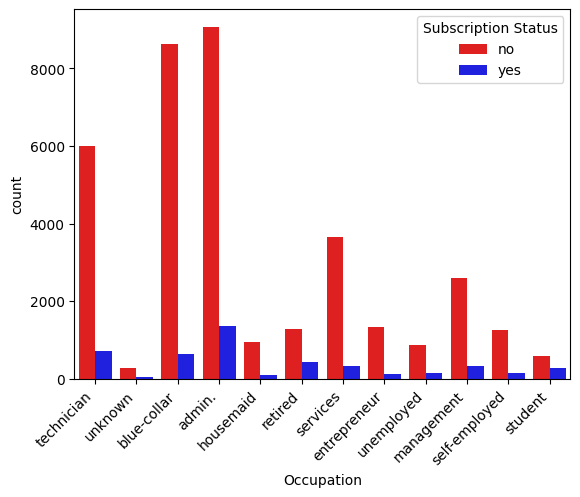

In [49]:
#
# Check data integrity and distribution
# *** Insights ****
#
# Categorical data, can be one-hot encoded
# Data skewed towards technicians, blue-collar and admin, can consider SMOTE/undersampling
#

display(df['Occupation'].value_counts())
display(df['Occupation'].value_counts()/df.shape[0])
sns.countplot(data=df, x=df['Occupation'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()

In [50]:
#
# One-hot encoding for Occupation column
# 

df_Occupation = df.copy()
df_Occupation_encoded = pd.get_dummies(df_Occupation, columns=['Occupation'], drop_first=True)
df_Occupation_encoded

,Client ID,Age,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,...,Occupation_entrepreneur,Occupation_housemaid,Occupation_management,Occupation_retired,Occupation_self-employed,Occupation_services,Occupation_student,Occupation_technician,Occupation_unemployed,Occupation_unknown
0,32885,57 years,married,high.school,no,no,yes,Cell,1,999,...,False,False,False,False,False,False,False,True,False,False
1,3170,55 years,married,unknown,unknown,yes,no,telephone,2,999,...,False,False,False,False,False,False,False,False,False,True
2,32207,33 years,married,basic.9y,no,no,no,cellular,1,999,...,False,False,False,False,False,False,False,False,False,False
3,9404,36 years,married,high.school,no,no,no,Telephone,4,999,...,False,False,False,False,False,False,False,False,False,False
4,14021,27 years,married,high.school,no,None,no,Cell,2,999,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58 years,married,professional.course,unknown,no,no,Telephone,2,999,...,False,False,False,True,False,False,False,False,False,False
41184,11285,37 years,married,university.degree,no,no,no,telephone,1,999,...,False,False,True,False,False,False,False,False,False,False
41185,38159,35 years,married,high.school,no,None,no,cellular,1,4,...,False,False,False,False,False,False,False,False,False,False
41186,861,40 years,married,university.degree,no,None,no,telephone,2,999,...,False,False,True,False,False,False,False,False,False,False


In [51]:
#
# Label encoding for target column Subscription Status
# 

df_Occupation_encoded['Subscription Status'] = df_Occupation_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 }).infer_objects(copy=False)
df_Occupation_encoded['Subscription Status']

C:\Users\Yik Heng\AppData\Local\Temp\ipykernel_26180\3797890677.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_Occupation_encoded['Subscription Status'] = df_Occupation_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 }).infer_objects(copy=False)


0        0
1        0
2        0
3        0
4        0
        ..
41183    0
41184    0
41185    1
41186    0
41187    0
Name: Subscription Status, Length: 41188, dtype: int64

<Axes: >

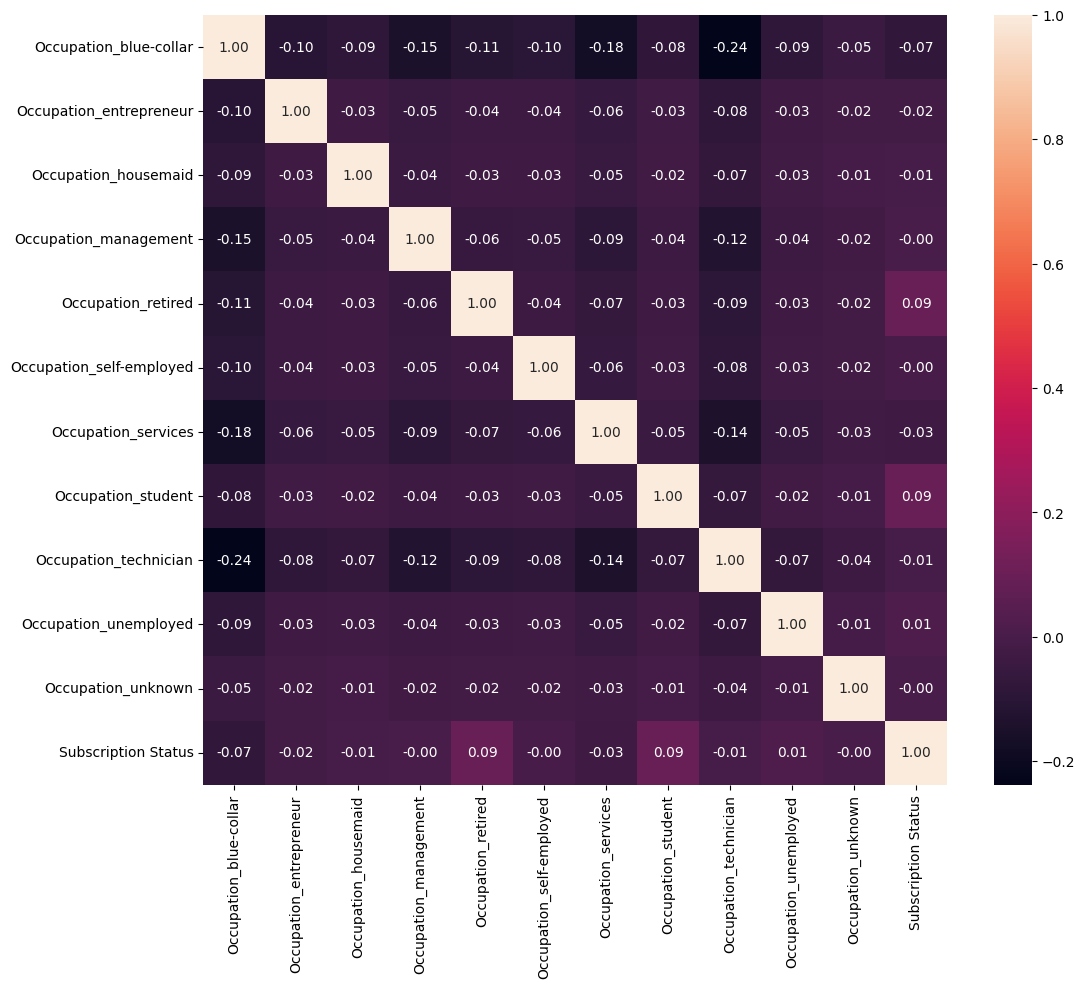

In [52]:
#
# Check correlation between Occupation types and target column
# *** Insights ****
#
# Weak linear correlation to target overall, with some types (blue collar, retired, student) having
# a slightly higher correlation
#

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_Occupation_encoded[[colname for colname in df_Occupation_encoded.columns if 'Occupation_' in colname] + ['Subscription Status']].corr(numeric_only=True), annot=True, fmt=".2f")

## Housing Loan

Housing Loan
None       24789
yes         8595
no          7411
unknown      393
Name: count, dtype: int64

Housing Loan
None       0.601850
yes        0.208677
no         0.179931
unknown    0.009542
Name: count, dtype: float64

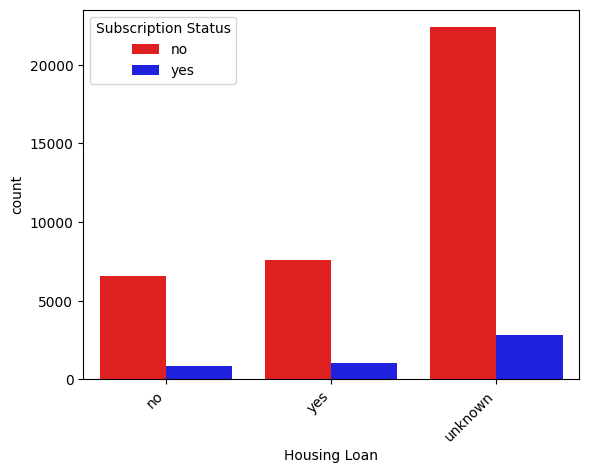

In [53]:
#
# Check data integrity and distribution
# *** Insights ****
#
# Categorical data, can be one-hot encoded
# >60% of the data is missing
# Missing data can be treated as 'unknown' due to lack of supporting information from other columns, hence making imputation unreliable
#

display(df['Housing Loan'].value_counts(dropna=False))
display(df['Housing Loan'].value_counts(dropna=False)/df.shape[0])
df_housing = df.copy()
df_housing['Housing Loan'] = df_housing['Housing Loan'].replace({ None: "unknown" })
sns.countplot(data=df_housing, x=df_housing['Housing Loan'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()

In [54]:
#
# One-hot encoding for Occupation column
# 

df_housing_encoded = pd.get_dummies(df_housing, columns=['Housing Loan'])
df_housing_encoded

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status,Housing Loan_no,Housing Loan_unknown,Housing Loan_yes
0,32885,57 years,technician,married,high.school,no,yes,Cell,1,999,no,True,False,False
1,3170,55 years,unknown,married,unknown,unknown,no,telephone,2,999,no,False,False,True
2,32207,33 years,blue-collar,married,basic.9y,no,no,cellular,1,999,no,True,False,False
3,9404,36 years,admin.,married,high.school,no,no,Telephone,4,999,no,True,False,False
4,14021,27 years,housemaid,married,high.school,no,no,Cell,2,999,no,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58 years,retired,married,professional.course,unknown,no,Telephone,2,999,no,True,False,False
41184,11285,37 years,management,married,university.degree,no,no,telephone,1,999,no,True,False,False
41185,38159,35 years,admin.,married,high.school,no,no,cellular,1,4,yes,False,True,False
41186,861,40 years,management,married,university.degree,no,no,telephone,2,999,no,False,True,False


In [55]:
#
# Label encoding for target column Subscription Status
# 

df_housing_encoded['Subscription Status'] = df_housing_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 }).infer_objects(copy=False)
df_housing_encoded['Subscription Status']

C:\Users\Yik Heng\AppData\Local\Temp\ipykernel_26180\295196644.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_housing_encoded['Subscription Status'] = df_housing_encoded['Subscription Status'].replace({ "no" : 0, "yes": 1 }).infer_objects(copy=False)


0        0
1        0
2        0
3        0
4        0
        ..
41183    0
41184    0
41185    1
41186    0
41187    0
Name: Subscription Status, Length: 41188, dtype: int64

C:\Users\Yik Heng\AppData\Local\Temp\ipykernel_26180\3354403955.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


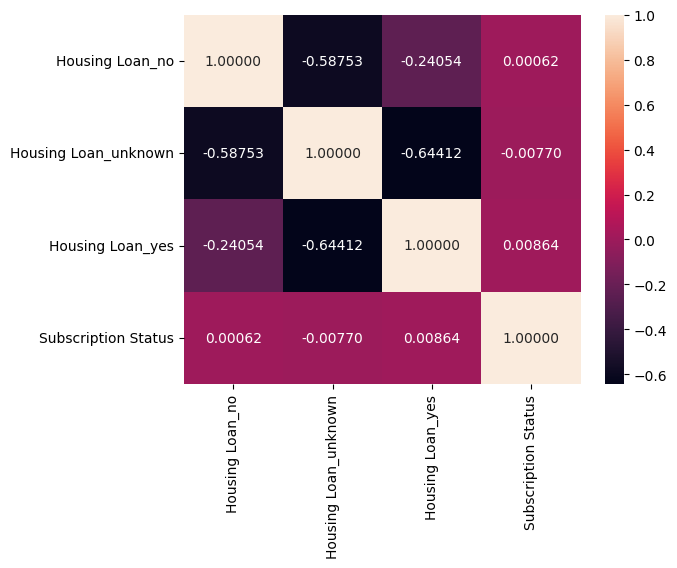

In [56]:
#
# Check correlation between Housing loan and target column
# *** Insights ****
#
# Little to no linear correlation to target
#

sns.heatmap(df_housing_encoded[[colname for colname in df_housing_encoded.columns if 'Housing Loan_' in colname] + ['Subscription Status']].corr(numeric_only=True), annot=True, fmt=".5f")
fig.show()

## Previous Contact Days

Previous Contact Days
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
19         3
22         3
21         2
26         1
27         1
20         1
25         1
Name: count, dtype: int64

Previous Contact Days
999    0.963217
3      0.010658
6      0.010003
4      0.002865
9      0.001554
2      0.001481
7      0.001457
12     0.001408
10     0.001263
5      0.001117
13     0.000874
11     0.000680
1      0.000631
15     0.000583
14     0.000486
8      0.000437
0      0.000364
16     0.000267
17     0.000194
18     0.000170
19     0.000073
22     0.000073
21     0.000049
26     0.000024
27     0.000024
20     0.000024
25     0.000024
Name: count, dtype: float64

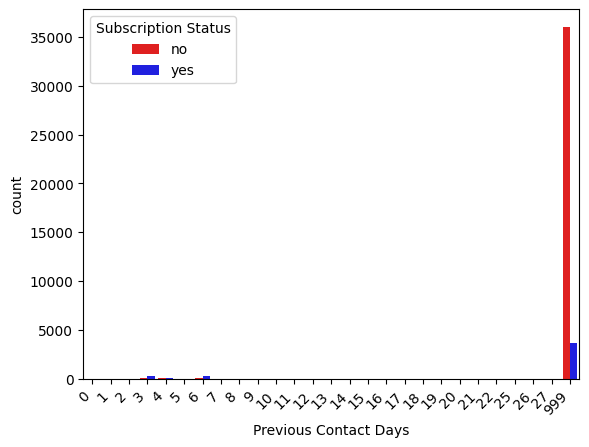

In [57]:
#
# Check data integrity and distribution
# *** Insights ****
#
# >96% is 999, highly skewing the data
# 

display(df['Previous Contact Days'].value_counts())
display(df['Previous Contact Days'].value_counts()/df.shape[0])

sns.countplot(data=df, x=df['Previous Contact Days'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()

Contacted
False    39673
True      1515
Name: count, dtype: int64

Contacted
False    0.963217
True     0.036783
Name: count, dtype: float64

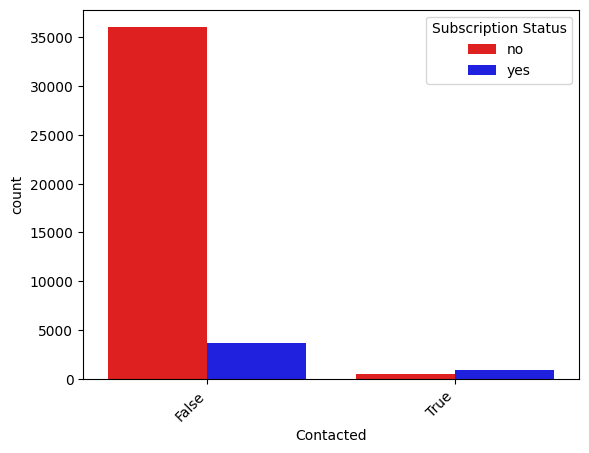

In [58]:
#
# Group according to who was contacted, and compare ratio of subscription status between those contacted and those not contacted
# *** Insights ****
#
# Those who were contacted has a slightly higher proportion of subscribers than non-subscribers
# Those who were not contacted had a significantly lower proportion of subscribers than non-subscribers
# Contacting customers makes them more likely to subscribe
# 

df_Contacted = df.copy()
df_Contacted['Contacted'] = df_Contacted['Previous Contact Days'] != 999

display(df_Contacted['Contacted'].value_counts())
display(df_Contacted['Contacted'].value_counts()/df.shape[0])

sns.countplot(data=df_Contacted, x=df_Contacted['Contacted'], hue='Subscription Status', palette={'no': 'red', 'yes': 'blue'})
plt.xticks(rotation=45, ha='right')
plt.show()